# Deep Cuisine Transfer — model

Trains the disentanglement seq2seq autoencoder (GRU encoder/decoder, style/content latent split, multi-task + adversarial classifiers in both directions), then does style transfer and evaluation.

**Run `01_preprocessing.ipynb` first.** It produces the artifacts this notebook loads:
- `data/recipes_train.csv`, `data/recipes_val.csv`, `data/recipes_test.csv`, `data/recipes_final.csv`
- `data/models/word2vec.wordvectors`
- `data/models/bow_vectorizer.joblib`

Training is resumable: rerunning the training cell picks up from `data/models/checkpoint_best_recon.pt` instead of starting over from random init.

In [1]:
import ast
import os

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from gensim.models import KeyedVectors
from torch.utils.data import Dataset, DataLoader

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

def load_split(name):
    df = pd.read_csv(f'./data/recipes_{name}.csv', index_col=0)
    df['steps_tokens'] = df['steps_tokens'].apply(ast.literal_eval)
    df['steps_tokens_bow'] = df['steps_tokens_bow'].apply(ast.literal_eval)
    return df

train_df = load_split('train')
val_df = load_split('val')
test_df = load_split('test')

# name/steps (raw, human-readable text) for the style-transfer demo later - train/val/test
# splits only keep the tokenized columns, so this is joined back in by index when needed
df_final = pd.read_csv('./data/recipes_final.csv', index_col=0)[['name', 'steps']]

wv = KeyedVectors.load('./data/models/word2vec.wordvectors')

# the saved CountVectorizer was fit with analyzer=identity_analyzer (preprocessing.ipynb) -
# joblib/pickle only stores a reference to that function by name, so it must exist under this
# exact name here too or unpickling fails with AttributeError
def identity_analyzer(tokens):
    return tokens

vectorizer = joblib.load('./data/models/bow_vectorizer.joblib')

X_train_bow = vectorizer.transform(train_df['steps_tokens_bow'])
X_val_bow = vectorizer.transform(val_df['steps_tokens_bow'])
X_test_bow = vectorizer.transform(test_df['steps_tokens_bow'])

print(train_df.shape, val_df.shape, test_df.shape)

mps


(8637, 3) (1851, 3) (1851, 3)


/Users/rpesic/Work/faks/ml/deepCuisineTransfer/.venv/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator CountVectorizer from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
seq_len = int(train_df['steps_tokens'].apply(len).quantile(0.95))

def tokens_to_matrix(tokens, wv, seq_len):
    matrix = np.zeros((seq_len, wv.vector_size), dtype=np.float32)
    for i, token in enumerate(tokens[:seq_len]):
        if token in wv:
            matrix[i] = wv[token]
    return matrix

## Vocabulary and target indices (for CrossEntropyLoss)

In [3]:
PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN = '<PAD>', '<UNK>', '<SOS>', '<EOS>'

word2idx = dict(wv.key_to_index)
word2idx[PAD_TOKEN] = len(word2idx)
PAD_IDX = word2idx[PAD_TOKEN]
word2idx[UNK_TOKEN] = len(word2idx)
UNK_IDX = word2idx[UNK_TOKEN]
word2idx[SOS_TOKEN] = len(word2idx)
SOS_IDX = word2idx[SOS_TOKEN]
word2idx[EOS_TOKEN] = len(word2idx)
EOS_IDX = word2idx[EOS_TOKEN]

VOCAB_SIZE = len(word2idx)

def tokens_to_indices(tokens, word2idx, seq_len):
    # leave room for EOS, then pad - EOS is included in the loss (unlike PAD),
    # giving the model a signal for where to stop generating
    tokens = tokens[:seq_len - 1]
    indices = [word2idx.get(t, UNK_IDX) for t in tokens]
    indices.append(EOS_IDX)
    indices += [PAD_IDX] * (seq_len - len(indices))
    return indices

## GRU Encoder

In [4]:
class GRUEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, style_dim, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.style_dim = style_dim
        self.content_dim = hidden_dim - style_dim
        self.style_head = nn.Linear(hidden_dim, style_dim)
        self.content_head = nn.Linear(hidden_dim, self.content_dim)

    def forward(self, x, lengths):
        # pack so the GRU stops at each sequence's real last token instead of
        # continuing to update hidden state through trailing zero-padding
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)
        hidden = hidden.squeeze(0)                    # (batch, hidden_dim)
        hidden = self.dropout(hidden)                  # regularize before splitting into latents
        style_latent = self.style_head(hidden)          # (batch, style_dim)
        content_latent = self.content_head(hidden)       # (batch, content_dim)
        return style_latent, content_latent

# encoder turns each recipe into one hidden vector, split via two heads into
# style_latent (e.g. cuisine) and content_latent (recipe content)
input_dim = wv.vector_size
hidden_dim = 512
STYLE_DIM = 64
encoder = GRUEncoder(input_dim, hidden_dim, STYLE_DIM, dropout=0.2).to(device)

## GRU Decoder

In [5]:
vocab_size = VOCAB_SIZE
MAX_LEN = seq_len

def block_repeat_ngrams(logits_t, generated, ngram_size):
    # standard no-repeat-ngram decoding constraint: for each sequence in the batch, find
    # tokens that would complete an n-gram already seen earlier in that sequence, and ban them
    for b in range(logits_t.size(0)):
        seq = generated[b]
        if seq:
            # separate from the n-gram check below: that only catches a token repeating a
            # transition seen earlier in this exact sequence, so an immediate stutter like
            # "the the" slips through the first time it happens (nothing to compare it to yet)
            logits_t[b, seq[-1]] = float('-inf')
        if len(seq) < ngram_size - 1:
            continue
        prefix = tuple(seq[-(ngram_size - 1):])
        banned = {
            seq[i + ngram_size - 1]
            for i in range(len(seq) - ngram_size + 1)
            if tuple(seq[i:i + ngram_size - 1]) == prefix
        }
        if banned:
            logits_t[b, list(banned)] = float('-inf')
    return logits_t

class GRUDecoder(nn.Module):
    def __init__(self, hidden_dim, vocab_size, embed_dim, sos_idx, pad_idx, unk_idx, max_len, dropout=0.2):
        super().__init__()
        self.max_len = max_len
        self.sos_idx = sos_idx
        self.unk_idx = unk_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.gru_cell = nn.GRUCell(embed_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, hidden, target=None, teacher_forcing_ratio=0.5, no_repeat_ngram_size=0):
        # hidden: (batch, hidden_dim) - encoder context vector, used as initial GRU state
        batch_size = hidden.size(0)
        device = hidden.device
        max_len = target.size(1) if target is not None else self.max_len

        input_idx = torch.full((batch_size,), self.sos_idx, dtype=torch.long, device=device)
        h = hidden
        outputs = []
        generated = [[] for _ in range(batch_size)] if no_repeat_ngram_size > 0 else None

        for t in range(max_len):
            embedded = self.embedding(input_idx)   # (batch, embed_dim)
            embedded = self.dropout(embedded)       # regularize decoder input embedding
            h = self.gru_cell(embedded, h)          # (batch, hidden_dim)
            logits_t = self.fc_out(h)               # (batch, vocab_size)

            use_teacher_forcing = target is not None and torch.rand(1).item() < teacher_forcing_ratio
            if use_teacher_forcing:
                outputs.append(logits_t.unsqueeze(1))
                input_idx = target[:, t]
            else:
                if target is None:
                    # pure free-running generation - as opposed to a training step that simply
                    # wasn't teacher-forced this time (target is still the ground truth there,
                    # and masking <UNK> would zero out the loss gradient whenever the true next
                    # token actually is <UNK>). <UNK> is a training-target artifact for rare
                    # words, never a word we want to see in real generated output.
                    logits_t[:, self.unk_idx] = float('-inf')
                    if no_repeat_ngram_size > 0:
                        logits_t = block_repeat_ngrams(logits_t, generated, no_repeat_ngram_size)
                outputs.append(logits_t.unsqueeze(1))
                input_idx = logits_t.argmax(dim=-1)
                if no_repeat_ngram_size > 0:
                    for b in range(batch_size):
                        generated[b].append(input_idx[b].item())

        return torch.cat(outputs, dim=1)  # (batch, max_len, vocab_size)

decoder = GRUDecoder(hidden_dim, vocab_size, input_dim, SOS_IDX, PAD_IDX, UNK_IDX, MAX_LEN, dropout=0.2).to(device)

## Seq2Seq Autoencoder — training (input recipe = target recipe)

In [6]:
CUISINE2IDX = {'Italian': 0, 'Indian': 1}
BOW_VOCAB_SIZE = X_train_bow.shape[1]

class RecipeDataset(Dataset):
    def __init__(self, df, wv, word2idx, seq_len, cuisine2idx, bow_matrix):
        self.tokens = df['steps_tokens'].tolist()
        self.cuisines = df['cuisine'].tolist()
        self.wv = wv
        self.word2idx = word2idx
        self.seq_len = seq_len
        self.cuisine2idx = cuisine2idx
        self.bow_matrix = bow_matrix

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        tokens = self.tokens[idx]
        x = tokens_to_matrix(tokens, self.wv, self.seq_len)
        y = tokens_to_indices(tokens, self.word2idx, self.seq_len)
        length = max(1, min(len(tokens), self.seq_len))  # real (non-padded) token count fed to the encoder
        style_label = self.cuisine2idx[self.cuisines[idx]]
        bow_target = (self.bow_matrix[idx].toarray().ravel() > 0).astype(np.float32)  # multi-label word presence
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(style_label, dtype=torch.long),
            torch.tensor(bow_target, dtype=torch.float32),
        )

BATCH_SIZE = 32

train_dataset = RecipeDataset(train_df, wv, word2idx, seq_len, CUISINE2IDX, X_train_bow)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# held out from training, used every epoch below to detect overfitting instead of only
# checking generalization once at the very end (the separate "held-out test set evaluation"
# section further down)
val_dataset = RecipeDataset(val_df, wv, word2idx, seq_len, CUISINE2IDX, X_val_bow)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

class Seq2SeqAutoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x, lengths, target=None, teacher_forcing_ratio=0.5, no_repeat_ngram_size=0, return_latents=False):
        style_latent, content_latent = self.encoder(x, lengths)
        context = torch.cat([style_latent, content_latent], dim=-1)  # merge back for the decoder
        logits = self.decoder(
            context, target=target, teacher_forcing_ratio=teacher_forcing_ratio,
            no_repeat_ngram_size=no_repeat_ngram_size,
        )
        if return_latents:
            return logits, style_latent, content_latent
        return logits

recon_criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
style_criterion = nn.CrossEntropyLoss()
content_criterion = nn.BCEWithLogitsLoss()  # multi-label: each word independently yes/no
adv_style_criterion = nn.CrossEntropyLoss()
adv_content_criterion = nn.BCEWithLogitsLoss()

def categorical_entropy(logits):
    log_probs = torch.log_softmax(logits, dim=-1)
    return -(log_probs.exp() * log_probs).sum(dim=-1).mean()

def bernoulli_entropy(logits):
    # per-label entropy of an independent Bernoulli, computed via logsigmoid for stability.
    # mean (not sum) over labels so this stays on the same ~ln(2) scale as categorical_entropy
    # regardless of BOW_VOCAB_SIZE - summing over thousands of labels would dwarf every other loss term.
    log_p = F.logsigmoid(logits)
    log_1m_p = F.logsigmoid(-logits)
    p = log_p.exp()
    return -(p * log_p + (1 - p) * log_1m_p).mean(dim=-1).mean()

@torch.no_grad()
def evaluate_val_recon_loss(model, val_loader, device):
    # free-running (no teacher forcing), matching how the model is actually used at
    # inference/style-transfer time - a teacher-forced val loss would be optimistic
    was_training = model.training
    model.eval()
    total = 0.0
    for batch_x, batch_y, batch_len, _, _ in val_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        logits = model(batch_x, batch_len, target=batch_y, teacher_forcing_ratio=0.0)
        total += recon_criterion(logits.permute(0, 2, 1), batch_y).item()
    if was_training:
        model.train()
    return total / len(val_loader)

CHECKPOINT_PATH = './data/models/checkpoint.pt'
BEST_RECON_CHECKPOINT_PATH = './data/models/checkpoint_best_recon.pt'
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)

def make_checkpoint(epoch, best_recon_loss):
    return {
        'epoch': epoch,
        'best_recon_loss': best_recon_loss,
        'model': model.state_dict(),
        'style_classifier': style_classifier.state_dict(),
        'content_classifier': content_classifier.state_dict(),
        'adv_style_classifier': adv_style_classifier.state_dict(),
        'adv_content_classifier': adv_content_classifier.state_dict(),
        'hparams': {
            'input_dim': input_dim,
            'hidden_dim': hidden_dim,
            'style_dim': STYLE_DIM,
            'vocab_size': VOCAB_SIZE,
            'bow_vocab_size': BOW_VOCAB_SIZE,
            'seq_len': seq_len,
            'pad_idx': PAD_IDX,
            'sos_idx': SOS_IDX,
            'unk_idx': UNK_IDX,
        },
    }

# only build the model/classifiers/optimizers the first time this cell runs, so rerunning
# the cell resumes training instead of starting over from random init
if 'model' not in globals():
    model = Seq2SeqAutoencoder(encoder, decoder).to(device)
    style_classifier = nn.Linear(STYLE_DIM, len(CUISINE2IDX)).to(device)

    # content classifier: content_vector -> predicted BoW word presence
    content_classifier = nn.Sequential(
        nn.Linear(encoder.content_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, BOW_VOCAB_SIZE),
    ).to(device)

    # adversarial style classifier (J_adv(s) in the paper): content_latent should carry no style
    # info, so the encoder is trained to maximize this classifier's prediction entropy
    adv_style_classifier = nn.Sequential(
        nn.Linear(encoder.content_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, len(CUISINE2IDX)),
    ).to(device)

    # adversarial content classifier (J_adv(c) in the paper): style_latent should carry no content
    # info, so the encoder is trained to maximize this classifier's per-word prediction entropy
    adv_content_classifier = nn.Sequential(
        nn.Linear(encoder.style_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, BOW_VOCAB_SIZE),
    ).to(device)

    # paper: Adam for the autoencoder + multi-task heads, RMSProp for the adversarial discriminators.
    # weight_decay added as a general regularizer on the Adam side only - adding it to the
    # adversarial discriminators too would work against their job of becoming as strong as
    # possible each step, which is what makes the encoder's adversarial loss meaningful
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(style_classifier.parameters()) + list(content_classifier.parameters()),
        lr=1e-3, weight_decay=1e-5,
    )
    adv_style_optimizer = torch.optim.RMSprop(adv_style_classifier.parameters(), lr=1e-3)
    adv_content_optimizer = torch.optim.RMSprop(adv_content_classifier.parameters(), lr=1e-3)

    # resume from the best checkpoint on disk (e.g. after a kernel restart or an interrupted
    # run) instead of starting from random init
    best_recon_loss = float('inf')
    patience_counter = 0
    loss_history = []  # per-epoch metrics across all runs of this cell, for the loss-curve plot below
    if os.path.exists(BEST_RECON_CHECKPOINT_PATH):
        checkpoint = torch.load(BEST_RECON_CHECKPOINT_PATH, map_location=device, weights_only=False)
        if 'model' in checkpoint:
            model.load_state_dict(checkpoint['model'])
            style_classifier.load_state_dict(checkpoint['style_classifier'])
            content_classifier.load_state_dict(checkpoint['content_classifier'])
            adv_style_classifier.load_state_dict(checkpoint['adv_style_classifier'])
            adv_content_classifier.load_state_dict(checkpoint['adv_content_classifier'])
            # the stored value was tracked against TRAIN recon loss in earlier runs of this
            # notebook - not comparable to the validation-based criterion used from here on,
            # so recompute it directly on val_loader to get a correct starting baseline
            best_recon_loss = evaluate_val_recon_loss(model, val_loader, device)
            print(f"Resumed from {BEST_RECON_CHECKPOINT_PATH}, val recon loss {best_recon_loss:.4f}")
        else:
            # older checkpoint format: a bare encoder/decoder state_dict, no classifiers or
            # metadata - still a valid warm start since GRUEncoder/GRUDecoder are unchanged
            model.load_state_dict(checkpoint)
            best_recon_loss = evaluate_val_recon_loss(model, val_loader, device)
            print(f"Resumed encoder/decoder only from older-format {BEST_RECON_CHECKPOINT_PATH} (classifiers start fresh), val recon loss {best_recon_loss:.4f}")
    else:
        print(f"No checkpoint found at {BEST_RECON_CHECKPOINT_PATH}, training from scratch")

# rerun this cell as many times as you like - it resumes from the best checkpoint each time
NUM_EPOCHS = 20
TEACHER_FORCING_RATIO = 0.5
STYLE_LOSS_WEIGHT = 1.0
CONTENT_LOSS_WEIGHT = 1.0
ADV_STYLE_LOSS_WEIGHT = 2.0
ADV_CONTENT_LOSS_WEIGHT = 2.0
EARLY_STOPPING_PATIENCE = 5  # stop if val recon loss hasn't improved for this many epochs

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    style_classifier.train()
    content_classifier.train()
    adv_style_classifier.train()
    adv_content_classifier.train()
    total_loss = 0.0
    total_recon_loss = 0.0
    total_style_loss = 0.0
    total_content_loss = 0.0
    total_adv_style_encoder_loss = 0.0
    total_adv_content_encoder_loss = 0.0
    total_adv_style_clf_loss = 0.0
    total_adv_content_clf_loss = 0.0
    correct_adv_style = 0
    total_adv = 0

    for batch_x, batch_y, batch_len, batch_style, batch_bow in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        batch_style = batch_style.to(device)
        batch_bow = batch_bow.to(device)
        optimizer.zero_grad()

        logits, style_latent, content_latent = model(
            batch_x, batch_len, target=batch_y, teacher_forcing_ratio=TEACHER_FORCING_RATIO, return_latents=True
        )
        recon_loss = recon_criterion(logits.permute(0, 2, 1), batch_y)   # (batch, vocab_size, seq_len) vs (batch, seq_len)

        style_logits = style_classifier(style_latent)
        style_loss = style_criterion(style_logits, batch_style)

        content_logits = content_classifier(content_latent)
        content_loss = content_criterion(content_logits, batch_bow)

        # encoder wants both adversarial classifiers to be as uninformative (max-entropy) as possible
        adv_style_logits_for_encoder = adv_style_classifier(content_latent)
        adv_style_encoder_loss = -categorical_entropy(adv_style_logits_for_encoder)

        adv_content_logits_for_encoder = adv_content_classifier(style_latent)
        adv_content_encoder_loss = -bernoulli_entropy(adv_content_logits_for_encoder)

        loss = (
            recon_loss
            + STYLE_LOSS_WEIGHT * style_loss
            + CONTENT_LOSS_WEIGHT * content_loss
            + ADV_STYLE_LOSS_WEIGHT * adv_style_encoder_loss
            + ADV_CONTENT_LOSS_WEIGHT * adv_content_encoder_loss
        )
        loss.backward()
        optimizer.step()

        # adversarial classifiers are trained separately, on detached latents, to actually
        # get as good as possible at their task (the encoder above is fighting this)
        adv_style_optimizer.zero_grad()
        adv_style_clf_logits = adv_style_classifier(content_latent.detach())
        adv_style_clf_loss = adv_style_criterion(adv_style_clf_logits, batch_style)
        adv_style_clf_loss.backward()
        adv_style_optimizer.step()

        adv_content_optimizer.zero_grad()
        adv_content_clf_logits = adv_content_classifier(style_latent.detach())
        adv_content_clf_loss = adv_content_criterion(adv_content_clf_logits, batch_bow)
        adv_content_clf_loss.backward()
        adv_content_optimizer.step()

        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_style_loss += style_loss.item()
        total_content_loss += content_loss.item()
        total_adv_style_encoder_loss += adv_style_encoder_loss.item()
        total_adv_content_encoder_loss += adv_content_encoder_loss.item()
        total_adv_style_clf_loss += adv_style_clf_loss.item()
        total_adv_content_clf_loss += adv_content_clf_loss.item()
        correct_adv_style += (adv_style_clf_logits.argmax(dim=-1) == batch_style).sum().item()
        total_adv += batch_style.size(0)

    n_batches = len(train_loader)
    avg_recon_loss = total_recon_loss / n_batches
    avg_adv_style_clf_acc = correct_adv_style / total_adv
    val_recon_loss = evaluate_val_recon_loss(model, val_loader, device)
    print(
        f'epoch {epoch}/{NUM_EPOCHS} '
        f'| loss {total_loss / n_batches:.4f} '
        f'| recon {avg_recon_loss:.4f} | val_recon {val_recon_loss:.4f} | style {total_style_loss / n_batches:.4f} '
        f'| content {total_content_loss / n_batches:.4f} '
        f'| adv_style_enc {total_adv_style_encoder_loss / n_batches:.4f} | adv_style_clf {total_adv_style_clf_loss / n_batches:.4f} '
        f'| adv_content_enc {total_adv_content_encoder_loss / n_batches:.4f} | adv_content_clf {total_adv_content_clf_loss / n_batches:.4f} '
        f'| adv_style_clf_acc {avg_adv_style_clf_acc:.4f}'
    )

    # keyed by cumulative epoch count (len(loss_history) + 1), not the per-run `epoch` variable,
    # so the loss-curve plot below stays continuous across repeated runs of this cell
    loss_history.append({
        'epoch': len(loss_history) + 1,
        'recon_loss': avg_recon_loss,
        'val_recon_loss': val_recon_loss,
        'adv_style_clf_acc': avg_adv_style_clf_acc,
    })

    # checkpoint on validation recon loss, not train - train loss alone never reveals overfitting.
    # recon_loss doesn't monotonically improve either way (style/adv losses can pull it back up),
    # so the final epoch isn't necessarily the best - checkpoint whenever val loss improves instead
    if val_recon_loss < best_recon_loss:
        best_recon_loss = val_recon_loss
        patience_counter = 0
        torch.save(make_checkpoint(epoch, best_recon_loss), BEST_RECON_CHECKPOINT_PATH)
        print(f'  -> new best val recon loss {best_recon_loss:.4f}, saved to {BEST_RECON_CHECKPOINT_PATH}')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f'  -> val recon loss has not improved for {EARLY_STOPPING_PATIENCE} epochs, stopping early')
            break

torch.save(make_checkpoint(epoch, best_recon_loss), CHECKPOINT_PATH)

# everything downstream (style vectors, style transfer generation, held-out eval) should run
# on the best checkpoint seen so far, not whichever epoch this run happened to end on
best_checkpoint = torch.load(BEST_RECON_CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(best_checkpoint['model'])
style_classifier.load_state_dict(best_checkpoint['style_classifier'])
content_classifier.load_state_dict(best_checkpoint['content_classifier'])
adv_style_classifier.load_state_dict(best_checkpoint['adv_style_classifier'])
adv_content_classifier.load_state_dict(best_checkpoint['adv_content_classifier'])

Resumed from ./data/models/checkpoint_best_recon.pt, val recon loss 6.8124


epoch 1/20 | loss 2.8739 | recon 4.0676 | val_recon 6.5738 | style 0.0404 | content 0.0108 | adv_style_enc -0.6096 | adv_style_clf 0.7414 | adv_content_enc -0.0128 | adv_content_clf 0.0143 | adv_style_clf_acc 0.5663
  -> new best val recon loss 6.5738, saved to ./data/models/checkpoint_best_recon.pt


epoch 2/20 | loss 2.5924 | recon 3.8305 | val_recon 6.4492 | style 0.0271 | content 0.0128 | adv_style_enc -0.6264 | adv_style_clf 0.6595 | adv_content_enc -0.0126 | adv_content_clf 0.0132 | adv_style_clf_acc 0.6110
  -> new best val recon loss 6.4492, saved to ./data/models/checkpoint_best_recon.pt


epoch 3/20 | loss 2.6233 | recon 3.7566 | val_recon 6.3350 | style 0.0263 | content 0.0142 | adv_style_enc -0.5742 | adv_style_clf 0.6296 | adv_content_enc -0.0127 | adv_content_clf 0.0132 | adv_style_clf_acc 0.6531
  -> new best val recon loss 6.3350, saved to ./data/models/checkpoint_best_recon.pt


epoch 4/20 | loss 2.4961 | recon 3.6961 | val_recon 6.2480 | style 0.0146 | content 0.0146 | adv_style_enc -0.6019 | adv_style_clf 0.6543 | adv_content_enc -0.0127 | adv_content_clf 0.0133 | adv_style_clf_acc 0.6290
  -> new best val recon loss 6.2480, saved to ./data/models/checkpoint_best_recon.pt


...

epoch 15/20 | loss 2.3216 | recon 3.6049 | val_recon 6.0535 | style 0.0119 | content 0.0149 | adv_style_enc -0.6421 | adv_style_clf 0.6747 | adv_content_enc -0.0130 | adv_content_clf 0.0133 | adv_style_clf_acc 0.5897


epoch 16/20 | loss 2.3377 | recon 3.6060 | val_recon 6.0516 | style 0.0071 | content 0.0149 | adv_style_enc -0.6322 | adv_style_clf 0.6677 | adv_content_enc -0.0130 | adv_content_clf 0.0133 | adv_style_clf_acc 0.6038


epoch 17/20 | loss 2.3835 | recon 3.6189 | val_recon 6.0656 | style 0.0115 | content 0.0150 | adv_style_enc -0.6179 | adv_style_clf 0.6575 | adv_content_enc -0.0131 | adv_content_clf 0.0133 | adv_style_clf_acc 0.6151


epoch 18/20 | loss 2.4728 | recon 3.6292 | val_recon 6.1020 | style 0.0137 | content 0.0151 | adv_style_enc -0.5794 | adv_style_clf 0.6444 | adv_content_enc -0.0131 | adv_content_clf 0.0134 | adv_style_clf_acc 0.6351
  -> val recon loss has not improved for 5 epochs, stopping early


<All keys matched successfully>

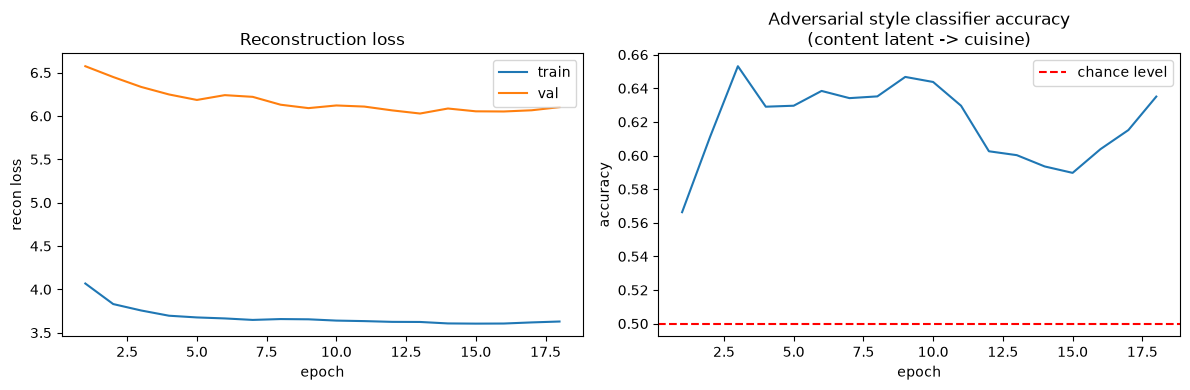

In [7]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(loss_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['epoch'], history_df['recon_loss'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_recon_loss'], label='val')
axes[0].set_title('Reconstruction loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('recon loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['adv_style_clf_acc'])
axes[1].axhline(0.5, color='red', linestyle='--', label='chance level')
axes[1].set_title('Adversarial style classifier accuracy\n(content latent -> cuisine)')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
idx2word = {idx: word for word, idx in word2idx.items()}
NO_REPEAT_NGRAM_SIZE = 3  # blocks repeated trigrams during free-running generation (greedy decoding loops otherwise)

model.eval()
with torch.no_grad():
    sample_x, sample_y, sample_len, sample_style, sample_bow = next(iter(train_loader))
    sample_x = sample_x.to(device)
    logits = model(
        sample_x, sample_len, target=None, teacher_forcing_ratio=0.0,
        no_repeat_ngram_size=NO_REPEAT_NGRAM_SIZE,
    )  # free-running generation, no teacher forcing
    predicted_indices = logits.argmax(dim=-1)  # (batch, seq_len)

def indices_to_tokens(indices):
    # stop at the first EOS - anything after it is not part of the generated content
    tokens = []
    for i in indices:
        if i == EOS_IDX:
            break
        if i != PAD_IDX:
            tokens.append(idx2word[i])
    return tokens

recipe_idx = 0
original_tokens = indices_to_tokens(sample_y[recipe_idx].tolist())
predicted_tokens = indices_to_tokens(predicted_indices[recipe_idx].tolist())

print('ORIGINAL: ', ' '.join(original_tokens))
print('PREDICTED:', ' '.join(predicted_tokens))

ORIGINAL:  soak the chicken breasts in the italian dressing for about 30 minutes then roll in bread crumbs place in baking dish and cook in oven for about 1 hour enjoy
PREDICTED: soak the chicken breasts in the dressing for 30 minutes then cut the bread in the baking dish in the oven for about 30 minutes


## Held-out test set evaluation

In [9]:
test_dataset = RecipeDataset(test_df, wv, word2idx, seq_len, CUISINE2IDX, X_test_bow)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

model.eval()
style_classifier.eval()
adv_style_classifier.eval()
total_recon, correct_style, correct_adv_style, n_batches, n_rows = 0.0, 0, 0, 0, 0
with torch.no_grad():
    for batch_x, batch_y, batch_len, batch_style, batch_bow in test_loader:
        batch_x, batch_y, batch_style = batch_x.to(device), batch_y.to(device), batch_style.to(device)
        logits, style_latent, content_latent = model(
            batch_x, batch_len, target=batch_y, teacher_forcing_ratio=0.0, return_latents=True
        )
        total_recon += recon_criterion(logits.permute(0, 2, 1), batch_y).item()
        correct_style += (style_classifier(style_latent).argmax(dim=-1) == batch_style).sum().item()
        correct_adv_style += (adv_style_classifier(content_latent).argmax(dim=-1) == batch_style).sum().item()
        n_batches += 1
        n_rows += batch_style.size(0)

print(f'test recon loss: {total_recon / n_batches:.4f}')
print(f'test style_clf accuracy (style latent -> cuisine): {correct_style / n_rows:.4f}')
print(f'test adv_style_clf accuracy (content latent -> cuisine, chance = 0.5): {correct_adv_style / n_rows:.4f}')

test recon loss: 6.0205
test style_clf accuracy (style latent -> cuisine): 0.9357
test adv_style_clf accuracy (content latent -> cuisine, chance = 0.5): 0.5300


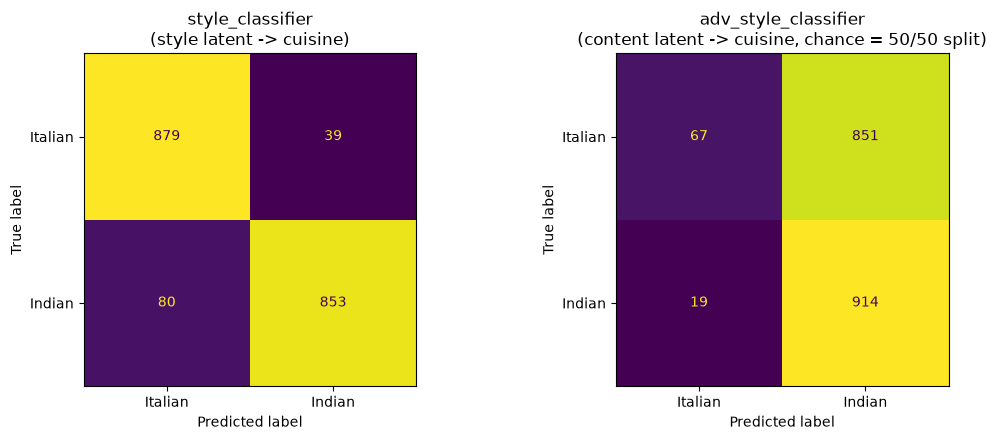

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

@torch.no_grad()
def collect_test_predictions(model, style_classifier, adv_style_classifier, test_loader, device):
    model.eval()
    style_classifier.eval()
    adv_style_classifier.eval()
    y_true, style_pred, adv_style_pred = [], [], []
    for batch_x, batch_y, batch_len, batch_style, _ in test_loader:
        batch_x = batch_x.to(device)
        style_latent, content_latent = model.encoder(batch_x, batch_len)
        y_true.extend(batch_style.tolist())
        style_pred.extend(style_classifier(style_latent).argmax(dim=-1).cpu().tolist())
        adv_style_pred.extend(adv_style_classifier(content_latent).argmax(dim=-1).cpu().tolist())
    return y_true, style_pred, adv_style_pred

y_true, style_pred, adv_style_pred = collect_test_predictions(
    model, style_classifier, adv_style_classifier, test_loader, device
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_true, style_pred, display_labels=['Italian', 'Indian'], ax=axes[0], colorbar=False
)
axes[0].set_title('style_classifier\n(style latent -> cuisine)')

ConfusionMatrixDisplay.from_predictions(
    y_true, adv_style_pred, display_labels=['Italian', 'Indian'], ax=axes[1], colorbar=False
)
axes[1].set_title('adv_style_classifier\n(content latent -> cuisine, chance = 50/50 split)')

plt.tight_layout()
plt.show()

## Style transfer

Average the style vectors of every training example within a cuisine class to get an empirical `Enc(S_T)` for that class (as in the paper's section 5.2). To transfer a recipe, encode it to get its content vector, discard its own style vector, and decode using the *target* cuisine's average style vector instead.

In [11]:
@torch.no_grad()
def compute_class_style_vectors(model, dataset, cuisine2idx, device, batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    style_sums = {idx: torch.zeros(model.encoder.style_dim, device=device) for idx in cuisine2idx.values()}
    style_counts = {idx: 0 for idx in cuisine2idx.values()}

    model.eval()
    for batch_x, _, batch_len, batch_style, _ in loader:
        batch_x = batch_x.to(device)
        batch_style = batch_style.to(device)
        style_latent, _ = model.encoder(batch_x, batch_len)
        for cls_idx in style_counts:
            mask = batch_style == cls_idx
            if mask.any():
                style_sums[cls_idx] += style_latent[mask].sum(dim=0)
                style_counts[cls_idx] += mask.sum().item()

    return {idx: style_sums[idx] / style_counts[idx] for idx in style_counts}

IDX2CUISINE = {idx: name for name, idx in CUISINE2IDX.items()}
class_style_vectors = compute_class_style_vectors(model, train_dataset, CUISINE2IDX, device)
for idx, vec in class_style_vectors.items():
    print(f"{IDX2CUISINE[idx]}: style vector norm = {vec.norm().item():.4f}")

# persist so a later session (or a separate generation script) doesn't need to re-run the
# whole training set through the encoder just to get these
for idx, vec in class_style_vectors.items():
    torch.save(vec, f'./data/models/style_avg_{IDX2CUISINE[idx].lower()}.pt')

Italian: style vector norm = 70.5886
Indian: style vector norm = 68.3618


In [12]:
@torch.no_grad()
def transfer_style(model, tokens, wv, seq_len, target_style_vector, device):
    model.eval()
    x = tokens_to_matrix(tokens, wv, seq_len)
    x = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
    length = torch.tensor([max(1, min(len(tokens), seq_len))], dtype=torch.long)

    _, content_latent = model.encoder(x, length)
    context = torch.cat([target_style_vector.unsqueeze(0), content_latent], dim=-1)
    logits = model.decoder(
        context, target=None, teacher_forcing_ratio=0.0, no_repeat_ngram_size=NO_REPEAT_NGRAM_SIZE,
    )  # free-running generation
    predicted_indices = logits.argmax(dim=-1).squeeze(0).tolist()
    return indices_to_tokens(predicted_indices)

OPPOSITE_CUISINE = {'Italian': 'Indian', 'Indian': 'Italian'}
N_PER_CUISINE = 6

# sample from val_df (held out, never seen during training) rather than train_df, and join
# back the raw name/steps text (dropped from the tokenized train/val/test splits) for a
# human-readable results table
demo_samples = pd.concat([
    g.sample(n=min(N_PER_CUISINE, len(g)), random_state=42)
    for _, g in val_df.groupby('cuisine')
]).join(df_final)
demo_samples['target_cuisine'] = demo_samples['cuisine'].map(OPPOSITE_CUISINE)

generated_texts = [
    ' '.join(transfer_style(model, row['steps_tokens'], wv, seq_len, class_style_vectors[CUISINE2IDX[row['target_cuisine']]], device))
    for _, row in demo_samples.iterrows()
]

results = pd.DataFrame({
    'recipe_name': demo_samples['name'].tolist(),
    'original_cuisine': demo_samples['cuisine'].tolist(),
    'original_text': demo_samples['steps'].tolist(),
    'generated_text': generated_texts,
    'target_cuisine': demo_samples['target_cuisine'].tolist(),
})
results.to_csv('./data/style_transfer_results.csv')

for _, row in results.head(4).iterrows():
    print(f"\n{row['recipe_name']} ({row['original_cuisine']} -> {row['target_cuisine']})")
    print('ORIGINAL:   ', row['original_text'])
    print('TRANSFERRED:', row['generated_text'])

results


roasted red bell pepper butter (Indian -> Italian)
ORIGINAL:    cut bell pepper in half. grill, turning oregularly, until the skin is blackened. remove from heat. place in a plastic sandwich bag for 15 minutes. remove bell pepper from bag after 15 minutes and peel it to remove stalk and seeds. slice thinly. combine bell pepper with lemon juice and salt. process till it becomes a smooth paste in your blender or mixer. add butter, pepper and dried basil. mix well. for a smooth paste, blend in a little olive oil, a tsp. at a time, until the ingredients hold together. serve with fish, vegetables or on warm bread. store this butter refrigerated for upto 1 week and frozen for upto 1 month.
TRANSFERRED: remove the from the and place in a large skillet over medium heat saute the garlic and garlic for about minutes until the peppers and the and the for about 10 minutes remove from the heat and cool slightly fill the with the with a spoon of the tomato sauce into the jar and the with salt and p

,recipe_name,original_cuisine,original_text,generated_text,target_cuisine
0,roasted red bell pepper butter,Indian,"cut bell pepper in half. grill, turning oregul...",remove the from the and place in a large skill...,Italian
1,nita mehta's shahi kaaju aloo,Indian,wash potatoes and peel. cut potatoes into 1 in...,preheat oven to 375°f peel and slice the into ...,Italian
2,bhindi bhaji,Indian,wash bhindi in water and dry it using cloth or...,if using wooden spoon or a or a knife or a sha...,Italian
3,ultimate lamb curry - tyler florence,Indian,start heating vegetable oil in a heavy dutch o...,to prepare the sauce heat oil in a large skill...,Italian
4,vegetable idli,Indian,heat oil in a pan. add mustard seeds. allow to...,heat oil in a pan add garlic and garlic and co...,Italian
5,indian scrambled eggs,Indian,melt butter. add chilies and onions. cook unti...,melt butter in a lg skillet over medium heat a...,Italian
6,george's pizza dough,Italian,"heat water to 105 to 115°f, dissolve sugar in ...",heat water in a large saucepan add wheat flour...,Indian
7,"onion confit, walnut and gorgonzola pizza",Italian,heat the oil in a large saute pan. add the oni...,heat the oil in a large pan and fry the onions...,Indian
8,classic minestrone,Italian,"in a soup pot, heat olive oil over medium flam...",in a large saucepan heat oil over medium heat ...,Indian
9,panna cotta (coffee/vanilla flavoured),Italian,"first, soak the gelatine leaves in a small bow...",first prepare the rice in a the pan and the an...,Indian


## Independent evaluation classifier

A separate classifier, trained only on the *original* (non-transferred) recipe text using averaged Word2Vec features. It never touches the autoencoder's style/content latents, so using it to score the style-transferred text afterwards isn't circular - it mirrors the paper's section 6 evaluation (84.5% accuracy on real text as a baseline, then the same classifier is used to measure how convincingly the transferred text reads as the target cuisine).

In [13]:
def recipe_to_avg_vector(tokens, wv):
    vectors = [wv[t] for t in tokens if t in wv]
    if not vectors:
        return np.zeros(wv.vector_size, dtype=np.float32)
    return np.mean(vectors, axis=0).astype(np.float32)

def build_eval_features(df, wv):
    X = np.stack([recipe_to_avg_vector(tokens, wv) for tokens in df['steps_tokens']])
    y = np.array([CUISINE2IDX[c] for c in df['cuisine']], dtype=np.int64)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

X_eval_train, y_eval_train = build_eval_features(train_df, wv)
X_eval_val, y_eval_val = build_eval_features(val_df, wv)
X_eval_train, y_eval_train = X_eval_train.to(device), y_eval_train.to(device)
X_eval_val, y_eval_val = X_eval_val.to(device), y_eval_val.to(device)

class StyleEvalClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, len(CUISINE2IDX)),
        )

    def forward(self, x):
        return self.net(x)

eval_classifier = StyleEvalClassifier(wv.vector_size).to(device)
eval_optimizer = torch.optim.Adam(eval_classifier.parameters(), lr=1e-3)
eval_criterion = nn.CrossEntropyLoss()

EVAL_EPOCHS = 30
EVAL_BATCH_SIZE = 64

for epoch in range(1, EVAL_EPOCHS + 1):
    eval_classifier.train()
    perm = torch.randperm(X_eval_train.size(0))
    total_loss = 0.0
    for start in range(0, X_eval_train.size(0), EVAL_BATCH_SIZE):
        idx = perm[start:start + EVAL_BATCH_SIZE]
        batch_x, batch_y = X_eval_train[idx], y_eval_train[idx]

        eval_optimizer.zero_grad()
        logits = eval_classifier(batch_x)
        loss = eval_criterion(logits, batch_y)
        loss.backward()
        eval_optimizer.step()
        total_loss += loss.item() * batch_x.size(0)

    if epoch % 5 == 0 or epoch == EVAL_EPOCHS:
        eval_classifier.eval()
        with torch.no_grad():
            val_acc = (eval_classifier(X_eval_val).argmax(dim=-1) == y_eval_val).float().mean().item()
        print(f"epoch {epoch:3d} | train_loss {total_loss / X_eval_train.size(0):.4f} | val_acc {val_acc:.4f}")

epoch   5 | train_loss 0.1698 | val_acc 0.9271


epoch  10 | train_loss 0.1453 | val_acc 0.9319


epoch  15 | train_loss 0.1263 | val_acc 0.9390


epoch  20 | train_loss 0.1108 | val_acc 0.9417


epoch  25 | train_loss 0.0971 | val_acc 0.9427


epoch  30 | train_loss 0.0822 | val_acc 0.9330


### Transfer strength

For held-out recipes (val_df, never seen by the autoencoder), transfer each to the *opposite* cuisine and check whether the independent classifier - trained only on real text - agrees that the result reads as the target style. This is the paper's transfer-strength metric (73% in the paper, vs. 84.5% on real text).

In [14]:
@torch.no_grad()
def score_transfer_strength(model, eval_classifier, df, wv, seq_len, class_style_vectors, cuisine2idx, device, sample_size=200):
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)

    correct = 0
    total = 0
    for _, row in sample_df.iterrows():
        source_idx = cuisine2idx[row['cuisine']]
        target_idx = 1 - source_idx
        transferred_tokens = transfer_style(
            model, row['steps_tokens'], wv, seq_len, class_style_vectors[target_idx], device
        )
        feature = torch.tensor(recipe_to_avg_vector(transferred_tokens, wv), dtype=torch.float32, device=device).unsqueeze(0)
        predicted_idx = eval_classifier(feature).argmax(dim=-1).item()
        correct += int(predicted_idx == target_idx)
        total += 1

    return correct / total

transfer_strength = score_transfer_strength(
    model, eval_classifier, val_df, wv, seq_len, class_style_vectors, CUISINE2IDX, device
)
print(f"Transfer strength (independent classifier agrees with target style): {transfer_strength:.4f}")

Transfer strength (independent classifier agrees with target style): 0.9500


### Content preservation

Transfer strength (above) only checks the *style* side of the paper's evaluation. This checks the other half: does the transferred text still describe the same cooking content as the original recipe?

Scored as a BoW word-presence F1 between the original recipe's `steps_tokens_bow` (ground truth content words) and the generated text's own BoW presence vector, both computed with the same `vectorizer` used to build the model's content-classifier targets. This is a direct lexical comparison, not a call into `content_classifier` or `adv_content_classifier` - those networks were trained adversarially against this same encoder, so scoring with them would be circular (analogous to why transfer strength uses an independent classifier rather than the model's own `style_classifier`).

In [15]:
def bow_presence_vector(tokens, vectorizer):
    return (vectorizer.transform([tokens]).toarray().ravel() > 0)

def content_preservation_f1(original_bow_tokens, generated_tokens, vectorizer):
    # multi-label word-presence F1, mirroring the binary target content_classifier is
    # trained against (self.bow_matrix[idx].toarray().ravel() > 0) - just computed directly
    # on tokens instead of through a trained network
    original_vec = bow_presence_vector(original_bow_tokens, vectorizer)
    generated_vec = bow_presence_vector(generated_tokens, vectorizer)
    tp = np.logical_and(original_vec, generated_vec).sum()
    if tp == 0:
        return 0.0
    precision = tp / generated_vec.sum()
    recall = tp / original_vec.sum()
    return 2 * precision * recall / (precision + recall)

In [16]:
# score the same demo examples shown after style transfer above, so the two tables
# stay directly comparable (same recipes, same generated_texts)
results['content_preservation_f1'] = [
    content_preservation_f1(bow_tokens, generated_text.split(), vectorizer)
    for bow_tokens, generated_text in zip(demo_samples['steps_tokens_bow'], generated_texts)
]
results.to_csv('./data/style_transfer_results.csv')

print(results[['recipe_name', 'original_cuisine', 'target_cuisine', 'content_preservation_f1']])

                                        recipe_name original_cuisine  \
0                    roasted red bell pepper butter           Indian   
1                     nita mehta's shahi kaaju aloo           Indian   
2                                      bhindi bhaji           Indian   
3              ultimate lamb curry - tyler florence           Indian   
4                                    vegetable idli           Indian   
5                             indian scrambled eggs           Indian   
6                              george's pizza dough          Italian   
7         onion confit, walnut and gorgonzola pizza          Italian   
8                                classic minestrone          Italian   
9            panna cotta (coffee/vanilla flavoured)          Italian   
10   goat cheese and caramelized onion phyllo bites          Italian   
11  agnello alla fiorentina (lamb florentine style)          Italian   

   target_cuisine  content_preservation_f1  
0         Italian 

In [17]:
@torch.no_grad()
def score_content_preservation(model, df, wv, seq_len, class_style_vectors, cuisine2idx, vectorizer, device, sample_size=200):
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)

    scores = []
    for _, row in sample_df.iterrows():
        source_idx = cuisine2idx[row['cuisine']]
        target_idx = 1 - source_idx
        transferred_tokens = transfer_style(
            model, row['steps_tokens'], wv, seq_len, class_style_vectors[target_idx], device
        )
        scores.append(content_preservation_f1(row['steps_tokens_bow'], transferred_tokens, vectorizer))

    return float(np.mean(scores))

# same val_df sample_size=200 as score_transfer_strength above, so the two metrics are
# reported on the same held-out slice
content_preservation = score_content_preservation(
    model, val_df, wv, seq_len, class_style_vectors, CUISINE2IDX, vectorizer, device
)
print(f"Content preservation (BoW word-presence F1, original vs. transferred): {content_preservation:.4f}")

Content preservation (BoW word-presence F1, original vs. transferred): 0.2518


## Ablation: does the adversarial loss actually help?

Trains a second model from scratch with `ADV_STYLE_LOSS_WEIGHT = ADV_CONTENT_LOSS_WEIGHT = 0` - everything else (architecture, multi-task losses, optimizers, dropout, early stopping) identical to the main model above. The adversarial discriminators are still trained (so they can still be used to *measure* leakage), they just no longer push back on the encoder.

Compared on two metrics: how much cuisine info leaks into the content latent (adversarial probe accuracy, chance = 0.5), and content preservation F1 after style transfer.

In [18]:
def run_ablation_training(adv_style_weight, adv_content_weight, max_epochs=10, patience=3):
    ab_encoder = GRUEncoder(input_dim, hidden_dim, STYLE_DIM, dropout=0.2).to(device)
    ab_decoder = GRUDecoder(hidden_dim, vocab_size, input_dim, SOS_IDX, PAD_IDX, UNK_IDX, MAX_LEN, dropout=0.2).to(device)
    ab_model = Seq2SeqAutoencoder(ab_encoder, ab_decoder).to(device)
    ab_style_classifier = nn.Linear(STYLE_DIM, len(CUISINE2IDX)).to(device)
    ab_content_classifier = nn.Sequential(
        nn.Linear(ab_encoder.content_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, BOW_VOCAB_SIZE)
    ).to(device)
    ab_adv_style_classifier = nn.Sequential(
        nn.Linear(ab_encoder.content_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, len(CUISINE2IDX))
    ).to(device)
    ab_adv_content_classifier = nn.Sequential(
        nn.Linear(ab_encoder.style_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, BOW_VOCAB_SIZE)
    ).to(device)

    ab_optimizer = torch.optim.Adam(
        list(ab_model.parameters()) + list(ab_style_classifier.parameters()) + list(ab_content_classifier.parameters()),
        lr=1e-3, weight_decay=1e-5,
    )
    ab_adv_style_optimizer = torch.optim.RMSprop(ab_adv_style_classifier.parameters(), lr=1e-3)
    ab_adv_content_optimizer = torch.optim.RMSprop(ab_adv_content_classifier.parameters(), lr=1e-3)

    best_val = float('inf')
    patience_ctr = 0
    best_state = None
    for epoch in range(1, max_epochs + 1):
        ab_model.train()
        ab_style_classifier.train()
        ab_content_classifier.train()
        ab_adv_style_classifier.train()
        ab_adv_content_classifier.train()

        for batch_x, batch_y, batch_len, batch_style, batch_bow in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            batch_style, batch_bow = batch_style.to(device), batch_bow.to(device)
            ab_optimizer.zero_grad()

            logits, style_latent, content_latent = ab_model(
                batch_x, batch_len, target=batch_y, teacher_forcing_ratio=TEACHER_FORCING_RATIO, return_latents=True
            )
            recon_loss = recon_criterion(logits.permute(0, 2, 1), batch_y)
            style_loss = style_criterion(ab_style_classifier(style_latent), batch_style)
            content_loss = content_criterion(ab_content_classifier(content_latent), batch_bow)

            adv_style_loss_enc = -categorical_entropy(ab_adv_style_classifier(content_latent))
            adv_content_loss_enc = -bernoulli_entropy(ab_adv_content_classifier(style_latent))

            loss = (
                recon_loss
                + STYLE_LOSS_WEIGHT * style_loss
                + CONTENT_LOSS_WEIGHT * content_loss
                + adv_style_weight * adv_style_loss_enc
                + adv_content_weight * adv_content_loss_enc
            )
            loss.backward()
            ab_optimizer.step()

            # discriminators are always trained to convergence, regardless of adv_*_weight,
            # so they remain valid *probes* for measuring leakage even when weight=0 means
            # the encoder above isn't being pushed to fool them
            ab_adv_style_optimizer.zero_grad()
            adv_style_clf_loss = adv_style_criterion(ab_adv_style_classifier(content_latent.detach()), batch_style)
            adv_style_clf_loss.backward()
            ab_adv_style_optimizer.step()

            ab_adv_content_optimizer.zero_grad()
            adv_content_clf_loss = adv_content_criterion(ab_adv_content_classifier(style_latent.detach()), batch_bow)
            adv_content_clf_loss.backward()
            ab_adv_content_optimizer.step()

        val_recon = evaluate_val_recon_loss(ab_model, val_loader, device)
        print(f'[ablation adv_weight={adv_style_weight}] epoch {epoch}/{max_epochs} | val_recon {val_recon:.4f}')

        if val_recon < best_val:
            best_val = val_recon
            patience_ctr = 0
            best_state = {
                'model': {k: v.clone() for k, v in ab_model.state_dict().items()},
                'adv_style_classifier': {k: v.clone() for k, v in ab_adv_style_classifier.state_dict().items()},
            }
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  -> stopping early at epoch {epoch}')
                break

    ab_model.load_state_dict(best_state['model'])
    ab_adv_style_classifier.load_state_dict(best_state['adv_style_classifier'])
    return ab_model, ab_adv_style_classifier

ablation_model, ablation_adv_style_classifier = run_ablation_training(
    adv_style_weight=0.0, adv_content_weight=0.0, max_epochs=10, patience=3
)

[ablation adv_weight=0.0] epoch 1/10 | val_recon 5.8948


[ablation adv_weight=0.0] epoch 2/10 | val_recon 5.8477


[ablation adv_weight=0.0] epoch 3/10 | val_recon 5.8074


[ablation adv_weight=0.0] epoch 4/10 | val_recon 5.7707


[ablation adv_weight=0.0] epoch 5/10 | val_recon 5.7344


[ablation adv_weight=0.0] epoch 6/10 | val_recon 5.7112


[ablation adv_weight=0.0] epoch 7/10 | val_recon 5.6882


[ablation adv_weight=0.0] epoch 8/10 | val_recon 5.6736


[ablation adv_weight=0.0] epoch 9/10 | val_recon 5.7109


[ablation adv_weight=0.0] epoch 10/10 | val_recon 5.6519


In [19]:
@torch.no_grad()
def test_adv_style_accuracy(model, adv_style_classifier, loader, device):
    model.eval()
    adv_style_classifier.eval()
    correct, total = 0, 0
    for batch_x, _, batch_len, batch_style, _ in loader:
        batch_x, batch_style = batch_x.to(device), batch_style.to(device)
        _, content_latent = model.encoder(batch_x, batch_len)
        correct += (adv_style_classifier(content_latent).argmax(dim=-1) == batch_style).sum().item()
        total += batch_style.size(0)
    return correct / total

main_adv_style_acc = test_adv_style_accuracy(model, adv_style_classifier, test_loader, device)
ablation_adv_style_acc = test_adv_style_accuracy(ablation_model, ablation_adv_style_classifier, test_loader, device)

# ablation model needs its own per-cuisine average style vectors before it can do style transfer
ablation_class_style_vectors = compute_class_style_vectors(ablation_model, train_dataset, CUISINE2IDX, device)
ablation_content_preservation = score_content_preservation(
    ablation_model, val_df, wv, seq_len, ablation_class_style_vectors, CUISINE2IDX, vectorizer, device
)

print(f"Main model (with adversarial loss):     adv probe acc = {main_adv_style_acc:.4f}, content preservation F1 = {content_preservation:.4f}")
print(f"Ablation model (no adversarial loss):    adv probe acc = {ablation_adv_style_acc:.4f}, content preservation F1 = {ablation_content_preservation:.4f}")

Main model (with adversarial loss):     adv probe acc = 0.5300, content preservation F1 = 0.2518
Ablation model (no adversarial loss):    adv probe acc = 0.9384, content preservation F1 = 0.3727


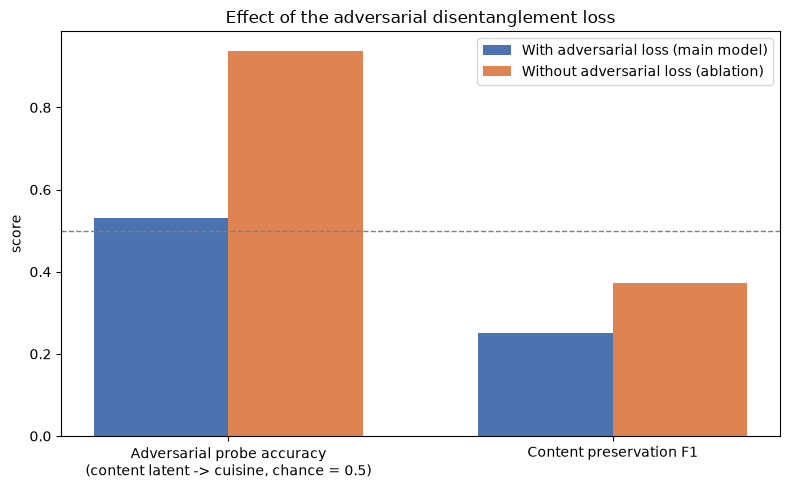

In [20]:
metrics = ['Adversarial probe accuracy\n(content latent -> cuisine, chance = 0.5)', 'Content preservation F1']
main_scores = [main_adv_style_acc, content_preservation]
ablation_scores = [ablation_adv_style_acc, ablation_content_preservation]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, main_scores, width, label='With adversarial loss (main model)', color='#4C72B0')
ax.bar(x + width / 2, ablation_scores, width, label='Without adversarial loss (ablation)', color='#DD8452')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('score')
ax.set_title('Effect of the adversarial disentanglement loss')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusion:** the adversarial loss is doing real work on the axis it targets - without it, the adversarial probe recovers cuisine from the content latent almost perfectly (0.94 accuracy, vs. chance = 0.5); with it, the probe is barely above chance (0.53), confirming the encoder is genuinely suppressing style leakage into content.

That suppression isn't free, though: content preservation is *worse* with the adversarial loss (0.25 F1) than without it (0.37 F1). This is a known disentanglement/reconstruction-fidelity tradeoff - pushing the content latent to be uninformative about style also makes it a bit less informative about content. Since content preservation is weak in both configurations (0.25 and 0.37 are both far from a strong score), the low number isn't purely an adversarial-loss artifact - it points to a separate, more fundamental limitation (likely decoder/content-latent capacity) that regularization and the adversarial mechanism alone don't fix.